# P. putida Transfer Learning — Homogeneous vs Heterogeneous

This notebook demonstrates all three transfer learning cases using the same P. putida fitness data, varying only which conditions are included in source and target.

## Background

| | Description | `fc₁` transfer | Hidden + Predictor transfer | Alignment |
|---|---|---|---|---|
| **Homogeneous TL** | Source and target share the same conditions (same names, same count) | ✓ All layers transfer | ✓ | None needed |
| **HTL — same count, different names** | Both have *n* conditions but at least one differs | ✗ Skipped (feature identity mismatch) | ✓ | KL (VAE) / MMD (MLP) |
| **HTL — different count** | Source has *p* conditions, target has *q*, *p ≠ q* | ✗ Skipped (shape mismatch) | ✓ | KL (VAE) / MMD (MLP) |

The framework detects which case applies automatically from the data — no manual flags needed for DL models.

## Four Scenarios

| Scenario | Source conditions | Target conditions | Case |
|---|---|---|---|
| 1 | All 11 | All 11 (identical) | Homogeneous |
| 2 | 9 (7 shared + 2 source-only) | 9 (7 shared + 2 target-only) | HTL — same count, different names |
| 3 | All 11 | 7 (shared only) | HTL — source richer |
| 4 | 7 (shared only) | All 11 | HTL — target richer |

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('always')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import torch
from torch import device
import random

from omicstl.simulation_utils.data_utils import DatasetContainer
from omicstl.simulation_utils.model_utils import (
    fit_dl_model, fit_rf_model, predict_dl_model, predict_rf_model
)
from omicstl.r_utils import set_seed

plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

N_TRAIN, N_ENSEMBLE, N_TEST = 130, 18, 50
DATA_DIR = 'data/'

## 2. Load Data

In [2]:
source_raw = pd.read_csv(DATA_DIR + 'pputida_source.csv')
target_raw = pd.read_csv(DATA_DIR + 'pputida_target.csv')

ALL_CONDITIONS = [
    'd_glucose', 'sodium_citrate', 'sodium_octanoate', 'sodium_acetate',
    'sodium_benzoate', 'd_xylose', 'l_arabinose', 'sodium_chloride',
    'urea', 'ammonium_chloride', 'pH'
]

print(f'Source shape: {source_raw.shape}  |  Target shape: {target_raw.shape}')

Source shape: (261, 16)  |  Target shape: (198, 26)


## 3. Define Feature Sets for All Scenarios

In [3]:
# 7 conditions shared across all scenarios
SHARED_7 = ['sodium_octanoate', 'sodium_acetate', 'sodium_benzoate',
             'd_xylose', 'l_arabinose', 'urea', 'ammonium_chloride']

SOURCE_ONLY_2 = ['d_glucose', 'sodium_citrate']   # in source but not target (scenarios 2)
TARGET_ONLY_2 = ['sodium_chloride', 'pH']          # in target but not source (scenario 2)

SCENARIOS = {
    1: {'name': 'Scenario 1 — Homogeneous (11 vs 11)',
        'src': ALL_CONDITIONS,
        'tgt': ALL_CONDITIONS,
        'case': 'Homogeneous'},
    2: {'name': 'Scenario 2 — HTL same count (9 vs 9, 7 shared)',
        'src': SOURCE_ONLY_2 + SHARED_7,
        'tgt': SHARED_7 + TARGET_ONLY_2,
        'case': 'HTL — same count, different names'},
    3: {'name': 'Scenario 3 — HTL source richer (11 vs 7)',
        'src': ALL_CONDITIONS,
        'tgt': SHARED_7,
        'case': 'HTL — different count (source > target)'},
    4: {'name': 'Scenario 4 — HTL target richer (7 vs 11)',
        'src': SHARED_7,
        'tgt': ALL_CONDITIONS,
        'case': 'HTL — different count (target > source)'},
}

print('Feature sets:')
for k, s in SCENARIOS.items():
    shared = [c for c in s['src'] if c in s['tgt']]
    print(f"  {s['name']}")
    print(f"    src={len(s['src'])}  tgt={len(s['tgt'])}  shared={len(shared)}  "
          f"mode={s['case']}")

Feature sets:
  Scenario 1 — Homogeneous (11 vs 11)
    src=11  tgt=11  shared=11  mode=Homogeneous
  Scenario 2 — HTL same count (9 vs 9, 7 shared)
    src=9  tgt=9  shared=7  mode=HTL — same count, different names
  Scenario 3 — HTL source richer (11 vs 7)
    src=11  tgt=7  shared=7  mode=HTL — different count (source > target)
  Scenario 4 — HTL target richer (7 vs 11)
    src=7  tgt=11  shared=7  mode=HTL — different count (target > source)


## 4. Helper Function

Wraps the full pipeline (split → container → fit → evaluate) so each scenario is one call.

In [4]:
def run_scenario(scenario_id, param_grid):
    s = SCENARIOS[scenario_id]
    src_feats, tgt_feats = s['src'], s['tgt']

    # ── Prepare source and target DataFrames ──────────────────────────────
    src_df = source_raw[['Resp'] + src_feats].rename(columns={'Resp': 'response'})
    tgt_df = target_raw[['fitness'] + tgt_feats].rename(columns={'fitness': 'response'})

    # ── Split target ───────────────────────────────────────────────────────
    tgt_combo, tgt_test = train_test_split(
        tgt_df, train_size=N_TRAIN + N_ENSEMBLE, test_size=N_TEST, random_state=42)
    tgt_train, tgt_ensemble = train_test_split(
        tgt_combo, train_size=N_TRAIN, test_size=N_ENSEMBLE, random_state=42)

    # ── DatasetContainer ───────────────────────────────────────────────────
    datasets = DatasetContainer(
        source_data=src_df, target_data=tgt_train,
        target_ensemble_data=tgt_ensemble, target_test_data=[tgt_test])
    datasets.set_response_column('response')

    is_hetero = set(src_feats) != set(tgt_feats)

    # ── Fit models ─────────────────────────────────────────────────────────
    random.seed(42); torch.manual_seed(42)
    vae_results, vae_model, _ = fit_dl_model(
        datasets, 'mult_vae', device('cpu'), param_grid)

    random.seed(42); torch.manual_seed(42)
    mlp_results, mlp_model, _ = fit_dl_model(
        datasets, 'mult_mlp', device('cpu'), param_grid)

    random.seed(42); set_seed(42)
    rf_results, rf_model = fit_rf_model(
        datasets, encoder_model=vae_model if is_hetero else None)

    # ── Select best model by test RMSE ────────────────────────────────────
    def dl_rmse(df):
        row = df[df['model_id'] == 'target']
        return float(row['rmse'].values[0]) if len(row) else np.inf

    def rf_rmse(df):
        row = df[df['model_type'] == 'pred_ensemble_full']
        return float(row['rmse'].values[0]) if len(row) else np.inf

    registry = {
        'VAE': {'rmse': dl_rmse(vae_results), 'model': vae_model, 'type': 'dl'},
        'MLP': {'rmse': dl_rmse(mlp_results), 'model': mlp_model, 'type': 'dl'},
        'RF':  {'rmse': rf_rmse(rf_results),   'model': rf_model,  'type': 'rf'},
    }
    best_name = min(registry, key=lambda k: registry[k]['rmse'])
    best_info = registry[best_name]

    # ── Predict on test set ────────────────────────────────────────────────
    def predict(info, X):
        X_df = X[tgt_feats] if isinstance(X, pd.DataFrame) else \
               pd.DataFrame(X, columns=tgt_feats)
        if info['type'] == 'dl':
            return np.array(predict_dl_model(info['model'], X_df), dtype=float).flatten()
        preds = predict_rf_model(info['model'], X_df)
        pred_df = pd.DataFrame(preds)
        col = 'pred_ensemble' if 'pred_ensemble' in pred_df.columns else pred_df.columns[-1]
        return pred_df[col].values.astype(float)

    y_true = tgt_test['response'].values
    y_pred = predict(best_info, tgt_test)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae  = np.mean(np.abs(y_true - y_pred))
    r, _ = pearsonr(y_true, y_pred)

    # ── Print model RMSE table ─────────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  {s['name']}")
    print(f"  Mode : {s['case']}")
    print(f"  Src features: {len(src_feats)}   "
          f"Tgt features: {len(tgt_feats)}   "
          f"Shared: {len([c for c in src_feats if c in tgt_feats])}")
    print(f"  fc1 transfer: {'YES' if not is_hetero else 'NO (HTL)'}")
    print()
    for nm, inf in registry.items():
        marker = ' ← best' if nm == best_name else ''
        print(f"    {nm}: RMSE = {inf['rmse']:.4f}{marker}")
    print(f"\n  Test  RMSE={rmse:.4f}  MAE={mae:.4f}  r={r:.4f}")

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(s['name'], fontsize=11, fontweight='bold')

    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.6, color='steelblue',
               edgecolors='white', linewidths=0.4)
    lim = [min(y_true.min(), y_pred.min()) - 0.02,
           max(y_true.max(), y_pred.max()) + 0.02]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.set(xlabel='Actual fitness', ylabel='Predicted fitness',
           title=f'Predicted vs Actual ({best_name})', xlim=lim, ylim=lim)
    ax.text(0.05, 0.95, f'r = {r:.3f}\nRMSE = {rmse:.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='gray'))

    ax = axes[1]
    names  = list(registry.keys())
    rmses  = [registry[n]['rmse'] for n in names]
    colors = ['#27AE60' if n == best_name else '#AEB6BF' for n in names]
    ax.bar(names, rmses, color=colors, edgecolor='white', width=0.5)
    ax.set(ylabel='Test RMSE', title='Model comparison')
    ax.set_ylim(0, max(rmses) * 1.25)
    for i, v in enumerate(rmses):
        ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return {'scenario': s['name'], 'case': s['case'],
            'n_src': len(src_feats), 'n_tgt': len(tgt_feats),
            'n_shared': len([c for c in src_feats if c in tgt_feats]),
            'fc1_transfer': not is_hetero,
            'best_model': best_name,
            'test_rmse': round(rmse, 4), 'pearson_r': round(r, 4)}

## 5. Hyperparameter Grid

In [5]:
param_grid = {
    'dropout':         [0.25, 0.5],
    'n_latent_dims':   [2],
    'hidden_dim_base': [6],
    'lr':              [0.01, 0.001],
    'source_epochs':   [1000],
    'target_epochs':   [1000],
    'freeze':          ['none'],
    'weight_decay':    [1e-4, 1e-2],
    'gamma':           [1, 2, 3]
}

## 6. Scenario 1 — Homogeneous (11 vs 11)

Both source (KT2440) and target (PpJE3959) use all 11 conditions. Feature sets are identical so `is_heterogeneous = False` and all layers including `fc₁` transfer.

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empt


───────────────────────────────────────────────────────
  Scenario 1 — Homogeneous (11 vs 11)
  Mode : Homogeneous
  Src features: 11   Tgt features: 11   Shared: 11
  fc1 transfer: YES

    VAE: RMSE = 0.1251
    MLP: RMSE = 0.0653
    RF: RMSE = 0.0603 ← best

  Test  RMSE=0.0602  MAE=0.0494  r=0.8775


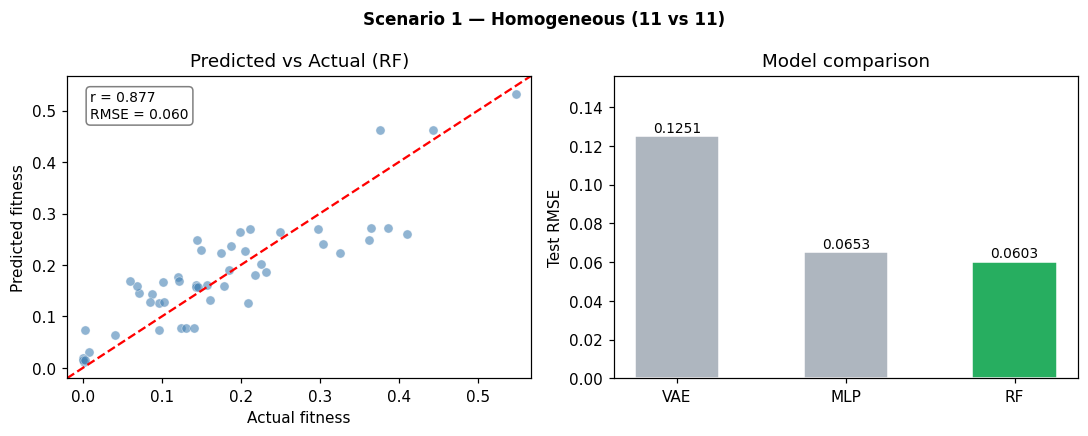

In [6]:
results_1 = run_scenario(1, param_grid)

## 7. Scenario 2 — HTL: Same Count, Different Names (9 vs 9)

Source has 9 conditions (7 shared + `d_glucose`, `sodium_citrate`).  
Target has 9 conditions (7 shared + `sodium_chloride`, `pH`).  

Shapes of `fc₁` happen to be identical (`9×h` on both sides), but the feature columns differ so `is_heterogeneous = True` and `fc₁` is **not** transferred. This is the case the shape-matching approach would have missed.

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empt


───────────────────────────────────────────────────────
  Scenario 2 — HTL same count (9 vs 9, 7 shared)
  Mode : HTL — same count, different names
  Src features: 9   Tgt features: 9   Shared: 7
  fc1 transfer: NO (HTL)

    VAE: RMSE = 0.1252
    MLP: RMSE = 0.1001
    RF: RMSE = 0.0720 ← best

  Test  RMSE=0.0721  MAE=0.0567  r=0.8276


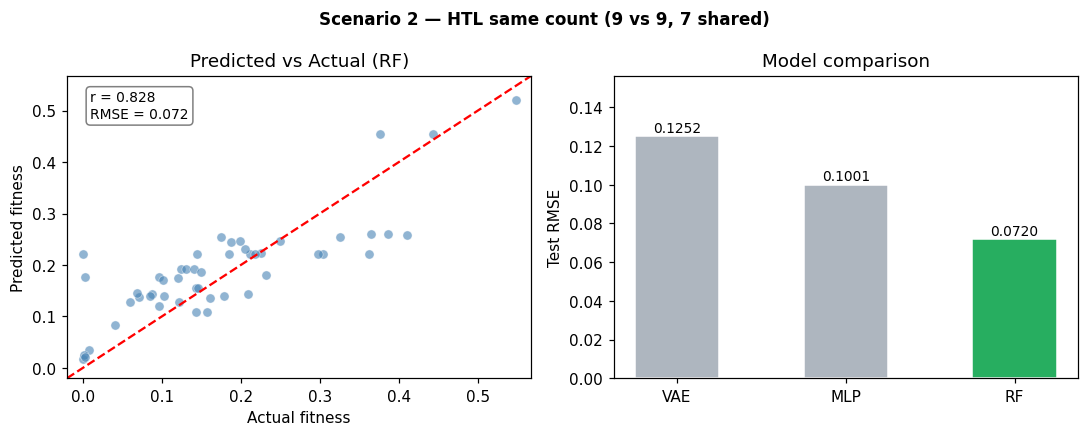

In [7]:
results_2 = run_scenario(2, param_grid)

## 8. Scenario 3 — HTL: Source Richer (11 vs 7)

Source has all 11 conditions; target has only the 7 shared conditions.  
Source `fc₁` is `11×h`, target `fc₁` is `7×h` — shapes differ so skipping is obvious, but `is_heterogeneous` ensures it even when shapes are equal.

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empt


───────────────────────────────────────────────────────
  Scenario 3 — HTL source richer (11 vs 7)
  Mode : HTL — different count (source > target)
  Src features: 11   Tgt features: 7   Shared: 7
  fc1 transfer: NO (HTL)

    VAE: RMSE = 0.1251
    MLP: RMSE = 0.1141
    RF: RMSE = 0.0674 ← best

  Test  RMSE=0.0674  MAE=0.0532  r=0.8471


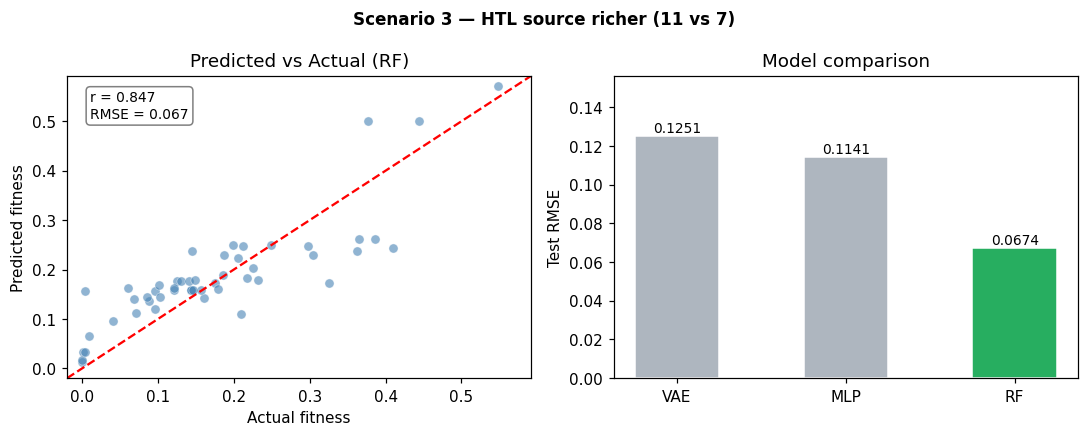

In [8]:
results_3 = run_scenario(3, param_grid)

## 9. Scenario 4 — HTL: Target Richer (7 vs 11)

Source has only the 7 shared conditions; target has all 11.  
The target encoder gets *more* input information than the source encoder — the reverse of Scenario 3.

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empt


───────────────────────────────────────────────────────
  Scenario 4 — HTL target richer (7 vs 11)
  Mode : HTL — different count (target > source)
  Src features: 7   Tgt features: 11   Shared: 7
  fc1 transfer: NO (HTL)

    VAE: RMSE = 0.1252
    MLP: RMSE = 0.0734
    RF: RMSE = 0.0646 ← best

  Test  RMSE=0.0646  MAE=0.0510  r=0.8565


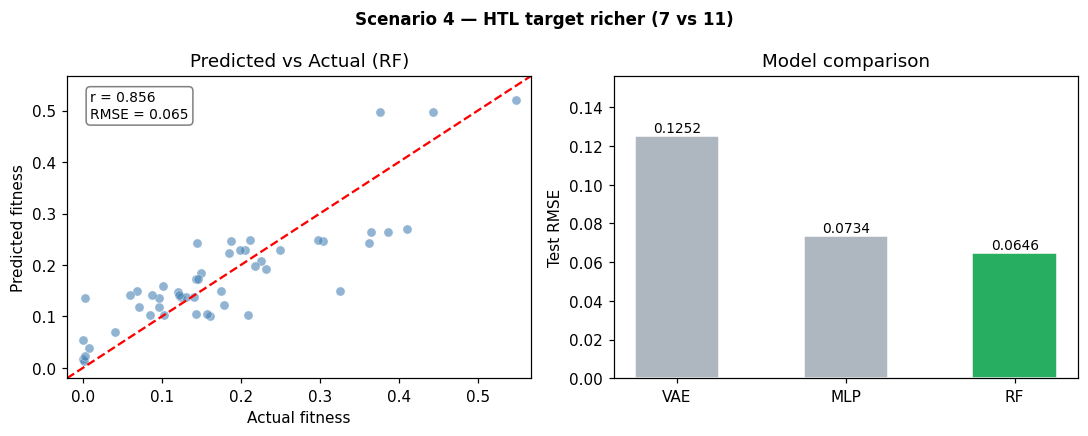

In [9]:
results_4 = run_scenario(4, param_grid)

## 10. Summary

In [10]:
summary = pd.DataFrame([results_1, results_2, results_3, results_4])
summary = summary.set_index('scenario')
summary.columns = ['TL case', 'Src feats', 'Tgt feats', 'Shared',
                   'fc1 transfer', 'Best model', 'Test RMSE', 'Pearson r']
display(summary)

,TL case,Src feats,Tgt feats,Shared,fc1 transfer,Best model,Test RMSE,Pearson r
scenario,,,,,,,,
Scenario 1 — Homogeneous (11 vs 11),Homogeneous,11,11,11,True,RF,0.0602,0.8775
"Scenario 2 — HTL same count (9 vs 9, 7 shared)","HTL — same count, different names",9,9,7,False,RF,0.0721,0.8276
Scenario 3 — HTL source richer (11 vs 7),HTL — different count (source > target),11,7,7,False,RF,0.0674,0.8471
Scenario 4 — HTL target richer (7 vs 11),HTL — different count (target > source),7,11,7,False,RF,0.0646,0.8565
